# CSC61304 - Machine Learning and Intelligent Systems

### BuddhaAI — Digital Wallet Transaction Fraud Detection (eSewa / Khalti context)

**Dataset:** Kaggle Credit Card Fraud Detection dataset (`creditcard.csv`)
Place `creditcard.csv` in the same folder as this notebook before running.
Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

This notebook implements the full ML pipeline: data loading, EDA, preprocessing,
two classification models (Logistic Regression baseline + Random Forest advanced)
with hyperparameter tuning, and rigorous evaluation.

## 1. Imports and Setup

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
from sklearn.utils import resample

try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ModuleNotFoundError:
    HAS_IMBLEARN = False

RANDOM_STATE = 42
DATA_PATH = "creditcard.csv"   # must sit in the same folder as this notebook

## 2. Load Data


In [6]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"'{DATA_PATH}' not found. Place creditcard.csv in the same directory "
        f"as this notebook (dataset: Kaggle Credit Card Fraud Detection)."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 3. Exploratory Data Analysis (EDA)


In [7]:
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum().sum())
print("\nCLASS DISTRIBUTION:\n", df["Class"].value_counts())
print("\nSUMMARY STATS (Amount):\n", df["Amount"].describe())

SHAPE: (21878, 31)

DTYPES:
 Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object

MISSING VALUES:
 2

CLASS DISTRIBUTION:
 Class
0.0    21791
1.0       86
Name: count, dtype: int64

SUMMARY STATS (Amount):
 count    21877.000000
mean        71.725300
std        205.034501
min          0.000000
25%          5.990000
50%         17.430000
75%         62.390000
max       7879.420000
Name: Amount, dtype: float64


### 3.1 EDA Plot 1 — Class Balance (severe imbalance expected)

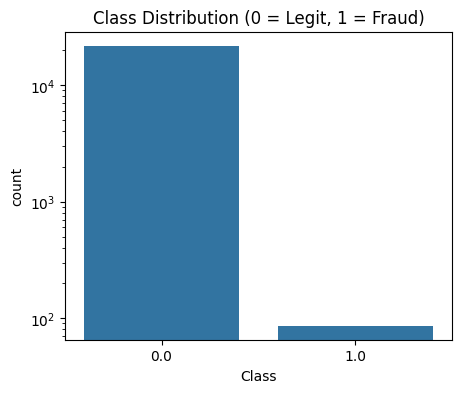

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.yscale("log")
plt.show()

### 3.2 EDA Plot 2 — Correlation Heatmap

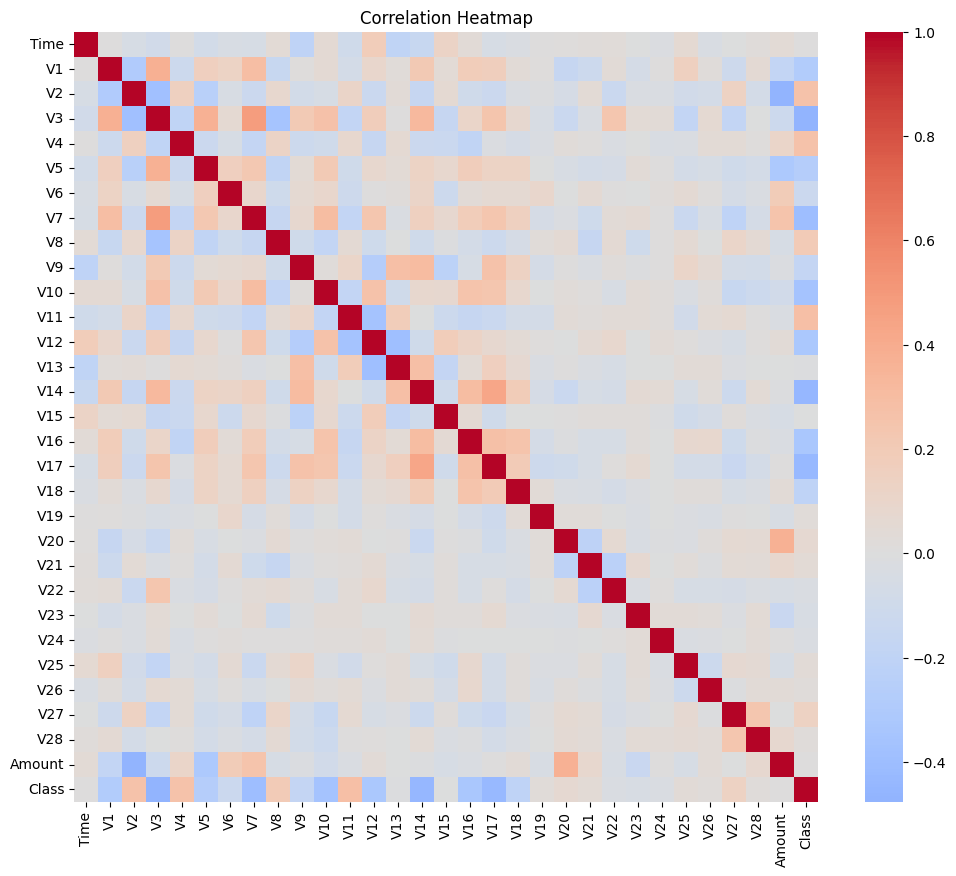

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### 3.3 EDA Plot 3 — Transaction Amount by Class (Boxplot)

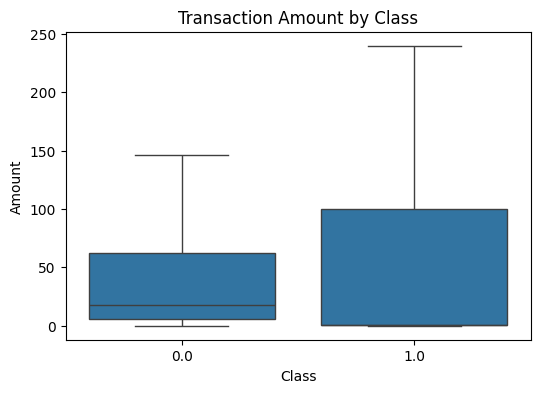

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Class", y="Amount", data=df, showfliers=False)
plt.title("Transaction Amount by Class")
plt.show()

### 3.4 EDA Plot 4 — Transaction Amount Histogram

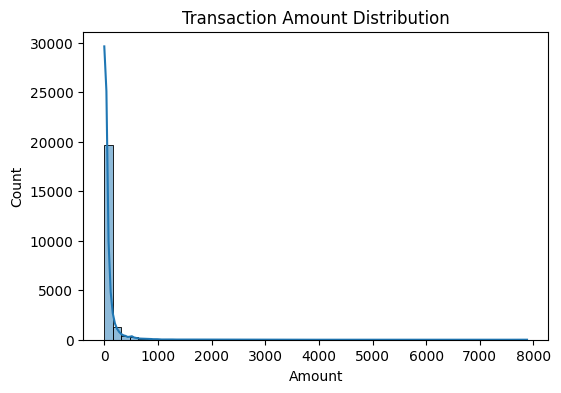

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

## 4. Data Preprocessing & Feature Engineering


In [12]:
data = df.copy()

scaler = StandardScaler()
data["Amount_scaled"] = scaler.fit_transform(data[["Amount"]])
data["Time_scaled"] = scaler.fit_transform(data[["Time"]])
data.drop(["Amount", "Time"], axis=1, inplace=True)

# Drop rows where 'Class' is NaN before splitting
data.dropna(subset=["Class"], inplace=True)

X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Before resampling:", y_train.value_counts().to_dict())

if HAS_IMBLEARN:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
else:
    train_df = pd.concat([X_train, y_train], axis=1)
    majority = train_df[train_df["Class"] == 0]
    minority = train_df[train_df["Class"] == 1]
    minority_upsampled = resample(
        minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE
    )
    train_res = pd.concat([majority, minority_upsampled])
    X_train_res = train_res.drop("Class", axis=1)
    y_train_res = train_res["Class"]

print("After resampling:", pd.Series(y_train_res).value_counts().to_dict())

Before resampling: {0.0: 17432, 1.0: 69}
After resampling: {0.0: 17432, 1.0: 17432}


## 5. Model Design & Implementation



### 5.1 Logistic Regression — baseline model + tuning

In [13]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr, scoring="f1", cv=cv, n_jobs=-1
)
grid_lr.fit(X_train_res, y_train_res)

lr_model = grid_lr.best_estimator_
print("Best params:", grid_lr.best_params_)

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


### 5.2 Random Forest — advanced model + tuning

In [14]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, scoring="f1", cv=cv, n_jobs=-1
)
grid_rf.fit(X_train_res, y_train_res)

rf_model = grid_rf.best_estimator_
print("Best params:", grid_rf.best_params_)

Best params: {'max_depth': 12, 'n_estimators': 100}


## 6. Evaluation & Comparison


--- Logistic Regression ---
Accuracy : 0.9854
Precision: 0.2099
Recall   : 1.0
F1-score : 0.3469
ROC-AUC  : 0.9986
Confusion Matrix:
 [[4295   64]
 [   0   17]]
              precision    recall  f1-score   support

         0.0     1.0000    0.9853    0.9926      4359
         1.0     0.2099    1.0000    0.3469        17

    accuracy                         0.9854      4376
   macro avg     0.6049    0.9927    0.6698      4376
weighted avg     0.9969    0.9854    0.9901      4376



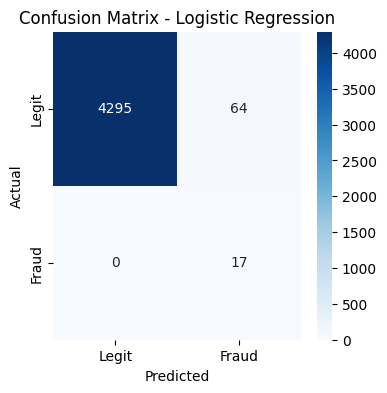

In [15]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {name} ---")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_test, y_pred, digits=4))

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return {
        "model": name, "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1, "roc_auc": auc, "y_pred": y_pred, "y_proba": y_proba,
    }

lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

--- Random Forest ---
Accuracy : 0.9993
Precision: 0.8889
Recall   : 0.9412
F1-score : 0.9143
ROC-AUC  : 0.9999
Confusion Matrix:
 [[4357    2]
 [   1   16]]
              precision    recall  f1-score   support

         0.0     0.9998    0.9995    0.9997      4359
         1.0     0.8889    0.9412    0.9143        17

    accuracy                         0.9993      4376
   macro avg     0.9443    0.9704    0.9570      4376
weighted avg     0.9993    0.9993    0.9993      4376



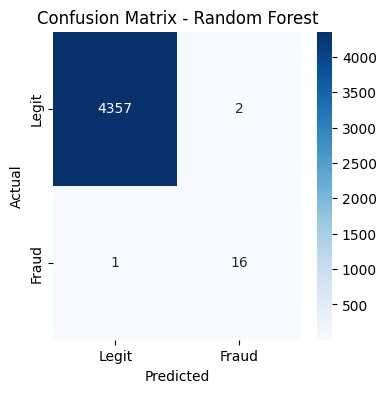

In [16]:
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

### 6.1 ROC Curve Comparison

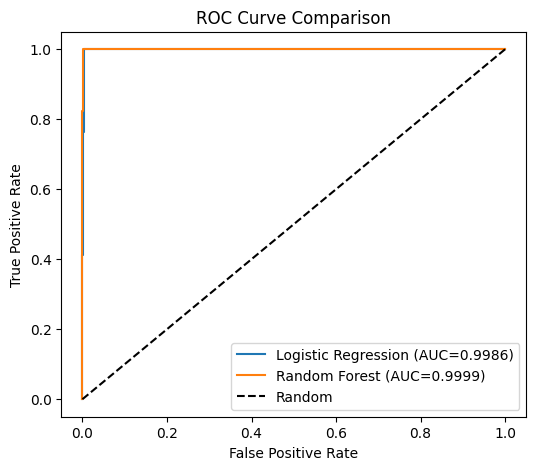

In [17]:
plt.figure(figsize=(6, 5))
for r in [lr_results, rf_results]:
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, label=f"{r['model']} (AUC={r['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 6.2 Side-by-Side Model Comparison Table

In [18]:
comparison_df = pd.DataFrame([lr_results, rf_results])[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]
comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.985375,0.209877,1.000000,0.346939,0.998583
1,Random Forest,0.999314,0.888889,0.941176,0.914286,0.999906


### 6.3 Error Analysis


In [19]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(rf_results["y_pred"])

misclassified = X_test_reset[y_test_reset != y_pred_series]
print(f"Total misclassified (Random Forest): {len(misclassified)}")
misclassified.head(5)

Total misclassified (Random Forest): 3


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Time_scaled
1572,-15.239440,10.096638,-18.579969,6.161424,-12.054621,-4.019253,-13.648636,10.250927,-2.868167,-9.733155,...,1.579344,-1.227214,-0.558447,0.035438,0.941530,-0.275561,1.700285,0.540294,0.089083,0.729724
3104,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,0.820391,-1.132403
3837,-17.950631,11.067069,-20.742660,6.075531,-13.389765,-4.532888,-15.188146,12.101062,-4.026880,-9.017413,...,1.797134,-1.275675,-0.705046,0.102040,1.177477,-0.238730,1.554463,0.547948,-0.344951,0.844398


## 7. Intelligent System Architecture Design


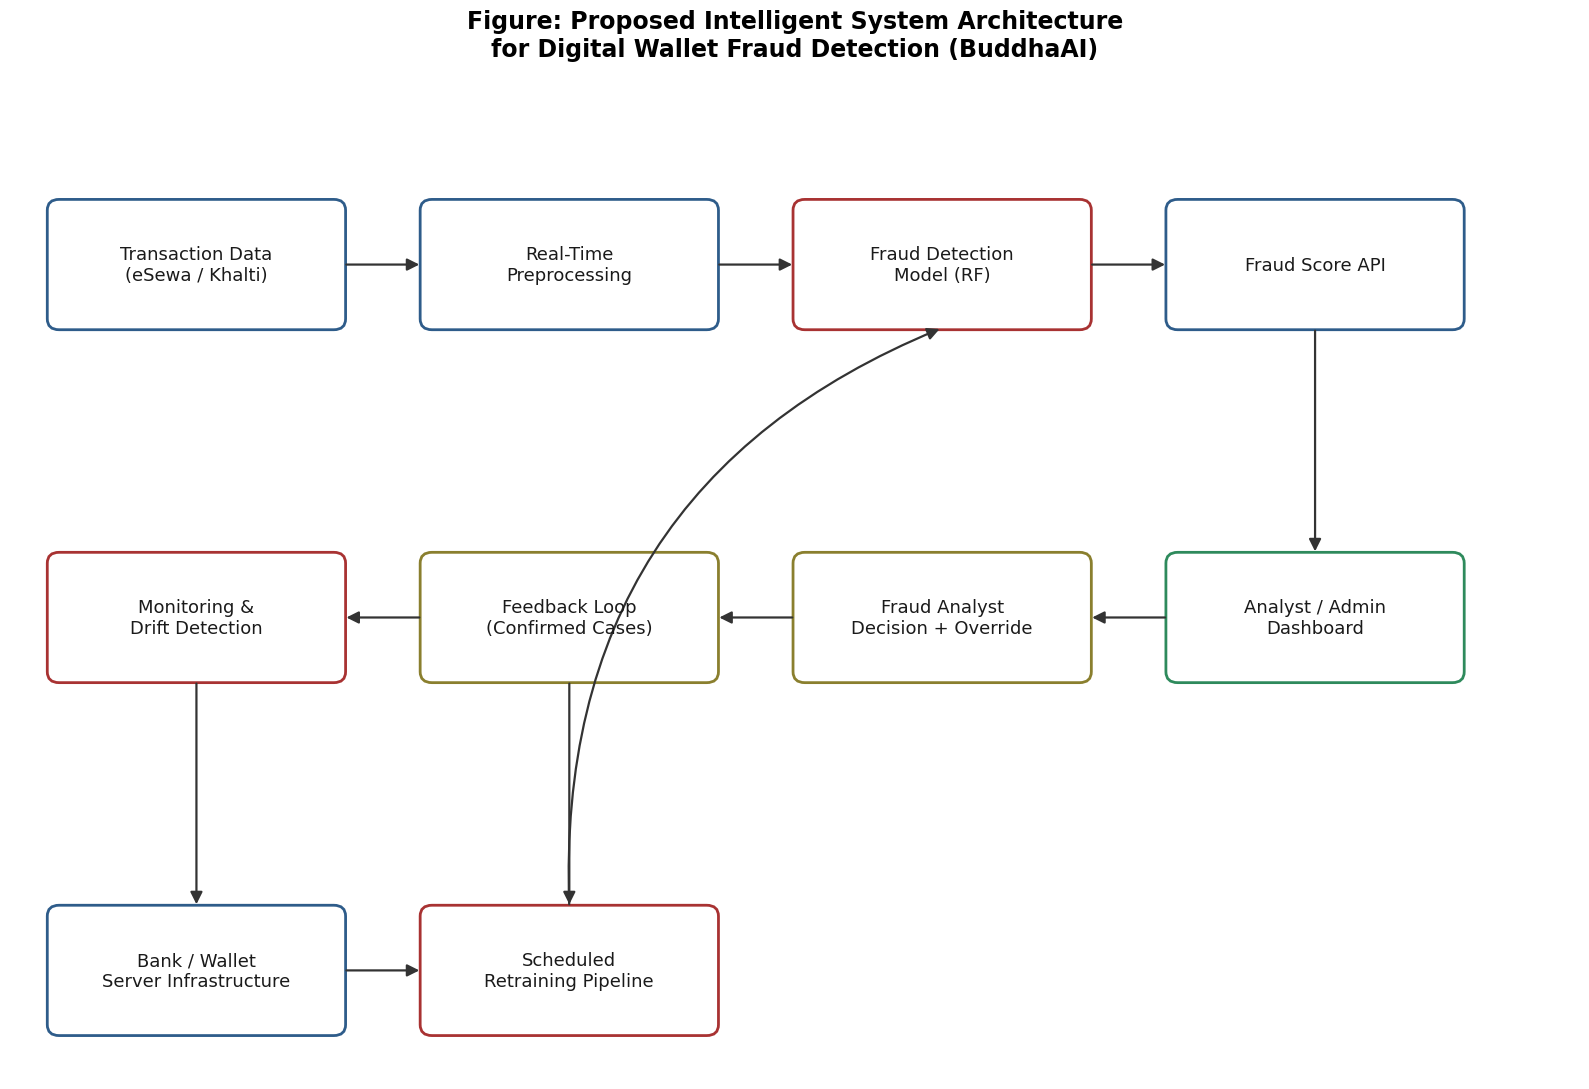

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 16)
ax.set_ylim(0, 11)
ax.axis('off')

blue, red, olive, green = '#2E5C8A', '#A83232', '#8A7F2E', '#2E8A5C'

boxes = {
    'data':     dict(xy=(0.4, 8.3), w=3.0, h=1.4, color=blue,  text="Transaction Data\n(eSewa / Khalti)"),
    'prep':     dict(xy=(4.2, 8.3), w=3.0, h=1.4, color=blue,  text="Real-Time\nPreprocessing"),
    'model':    dict(xy=(8.0, 8.3), w=3.0, h=1.4, color=red,   text="Fraud Detection\nModel (RF)"),
    'api':      dict(xy=(11.8, 8.3), w=3.0, h=1.4, color=blue, text="Fraud Score API"),
    'monitor':  dict(xy=(0.4, 4.4), w=3.0, h=1.4, color=red,   text="Monitoring &\nDrift Detection"),
    'feedback': dict(xy=(4.2, 4.4), w=3.0, h=1.4, color=olive, text="Feedback Loop\n(Confirmed Cases)"),
    'analyst':  dict(xy=(8.0, 4.4), w=3.0, h=1.4, color=olive, text="Fraud Analyst\nDecision + Override"),
    'ui':       dict(xy=(11.8, 4.4), w=3.0, h=1.4, color=green,text="Analyst / Admin\nDashboard"),
    'server':   dict(xy=(0.4, 0.5), w=3.0, h=1.4, color=blue,  text="Bank / Wallet\nServer Infrastructure"),
    'retrain':  dict(xy=(4.2, 0.5), w=3.0, h=1.4, color=red,   text="Scheduled\nRetraining Pipeline"),
}

for key, b in boxes.items():
    box = FancyBboxPatch(b['xy'], b['w'], b['h'], boxstyle="round,pad=0.02,rounding_size=0.12",
                          linewidth=2, edgecolor=b['color'], facecolor='white')
    ax.add_patch(box)
    cx, cy = b['xy'][0] + b['w']/2, b['xy'][1] + b['h']/2
    ax.text(cx, cy, b['text'], ha='center', va='center', fontsize=13, color='#1a1a1a')

def center_right(k): b = boxes[k]; return (b['xy'][0]+b['w'], b['xy'][1]+b['h']/2)
def center_left(k):  b = boxes[k]; return (b['xy'][0], b['xy'][1]+b['h']/2)
def center_top(k):   b = boxes[k]; return (b['xy'][0]+b['w']/2, b['xy'][1]+b['h'])
def center_bottom(k):b = boxes[k]; return (b['xy'][0]+b['w']/2, b['xy'][1])

def arrow(p1, p2, connectionstyle='arc3,rad=0.0'):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=18,
                                  linewidth=1.6, color='#333333', connectionstyle=connectionstyle))

arrow(center_right('data'), center_left('prep'))
arrow(center_right('prep'), center_left('model'))
arrow(center_right('model'), center_left('api'))
arrow(center_bottom('api'), center_top('ui'))
arrow(center_left('ui'), center_right('analyst'))
arrow(center_left('analyst'), center_right('feedback'))
arrow(center_left('feedback'), center_right('monitor'))
arrow(center_bottom('monitor'), center_top('server'))
arrow(center_bottom('feedback'), center_top('retrain'))
arrow(center_right('server'), center_left('retrain'))
arrow(center_top('retrain'), center_bottom('model'), connectionstyle='arc3,rad=-0.35')

plt.title("Figure: Proposed Intelligent System Architecture\nfor Digital Wallet Fraud Detection (BuddhaAI)",
          fontsize=17, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 8. Save Results


In [20]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Saved model_comparison.csv")

Saved model_comparison.csv
